In [8]:
def read_fasta(filename):
    sequences = {}
    with open(filename, "r") as f:
        current_id = None
        current_seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id:
                    sequences[current_id] = current_seq
                current_id = line[1:]
                current_seq = ""
            elif current_id and line:
                current_seq += line
        if current_id:
            sequences[current_id] = current_seq
    return sequences

amp = read_fasta("AMPlify_AMP_train_common.fa")
non_amp = read_fasta("AMPlify_non_AMP_train_balanced.fa")

print(f"AMP 수: {len(amp)}개")
print(f"비AMP 수: {len(non_amp)}개")

AMP 수: 3338개
비AMP 수: 3338개


In [3]:
import os
print(os.getcwd())

C:\Users\82107\Downloads


In [4]:
with open("results.fasta", "r") as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 10:
            break

'>Your search led to 1495 peptides\n'
'>AP00001\n'
'GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV\n'
'\n'
'>AP00004\n'
'NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC\n'
'\n'
'>AP00012\n'
'GLFDIIKKIAESI\n'
'\n'
'>AP00013\n'
'GLFDIIKKIAESF\n'


In [5]:
import pandas as pd

# 데이터 합치기
data = []

for seq_id, seq in amp.items():
    data.append({"id": seq_id, "sequence": seq, "label": 1})  # AMP = 1

for seq_id, seq in non_amp.items():
    data.append({"id": seq_id, "sequence": seq, "label": 0})  # 비AMP = 0

df = pd.DataFrame(data)

print(df.shape)
print(df.head())
print(df["label"].value_counts())

(6676, 3)
          id                                           sequence  label
0  trAMP0001                  GLLDTFKNLALNAAKSAGVSVLNSLSCKLSKTC      1
1  trAMP0002                                  AKKPVAKKAAGGVKKPK      1
2  trAMP0003                                GIIDIAKKLVGGIRNVLGI      1
3  trAMP0004  MAGFLKVVQLLAKYGSKAVQWAWANKGKILDWLNAGQAIDWVVSKI...      1
4  trAMP0005  YGPGDGHGGGHGGGHGGGHGNGQGGGHGHGPGGGFGGGHGGGHGGG...      1
label
1    3338
0    3338
Name: count, dtype: int64


In [6]:
def extract_features(seq):
    seq = seq.upper()
    length = len(seq)
    
    # 양전하 아미노산 (K, R)
    pos_charge = (seq.count("K") + seq.count("R")) / length
    
    # 음전하 아미노산 (D, E)
    neg_charge = (seq.count("D") + seq.count("E")) / length
    
    # 순전하
    net_charge = pos_charge - neg_charge
    
    # 소수성 아미노산 (A, V, I, L, M, F, W, P)
    hydrophobic = sum(seq.count(aa) for aa in "AVILMFWP") / length
    
    return {
        "length": length,
        "pos_charge": pos_charge,
        "neg_charge": neg_charge,
        "net_charge": net_charge,
        "hydrophobic": hydrophobic
    }

# 전체 데이터에 적용
features = df["sequence"].apply(extract_features)
df_features = pd.DataFrame(list(features))
df_features["label"] = df["label"]

print(df_features.head())

   length  pos_charge  neg_charge  net_charge  hydrophobic  label
0      33    0.121212    0.030303    0.090909     0.424242      1
1      17    0.411765    0.000000    0.411765     0.470588      1
2      19    0.157895    0.052632    0.105263     0.526316      1
3      53    0.150943    0.037736    0.113208     0.547170      1
4      84    0.011905    0.011905    0.000000     0.071429      1


In [9]:
print(df_features.columns.tolist())

['length', 'pos_charge', 'neg_charge', 'net_charge', 'hydrophobic', 'label']


In [10]:
def extract_features(seq):
    seq = seq.upper()
    length = len(seq)
    pos_charge = (seq.count("K") + seq.count("R")) / length
    neg_charge = (seq.count("D") + seq.count("E")) / length
    net_charge = pos_charge - neg_charge
    hydrophobic = sum(seq.count(aa) for aa in "AVILMFWP") / length
    aromatic = sum(seq.count(aa) for aa in "FWY") / length
    glycine = seq.count("G") / length
    proline = seq.count("P") / length

    return {
        "length": length,
        "pos_charge": pos_charge,
        "neg_charge": neg_charge,
        "net_charge": net_charge,
        "hydrophobic": hydrophobic,
        "aromatic": aromatic,
        "glycine": glycine,
        "proline": proline
    }

features = df["sequence"].apply(extract_features)
df_features = pd.DataFrame(list(features))
df_features["label"] = df["label"]

print(df_features.columns.tolist())

['length', 'pos_charge', 'neg_charge', 'net_charge', 'hydrophobic', 'aromatic', 'glycine', 'proline', 'label']


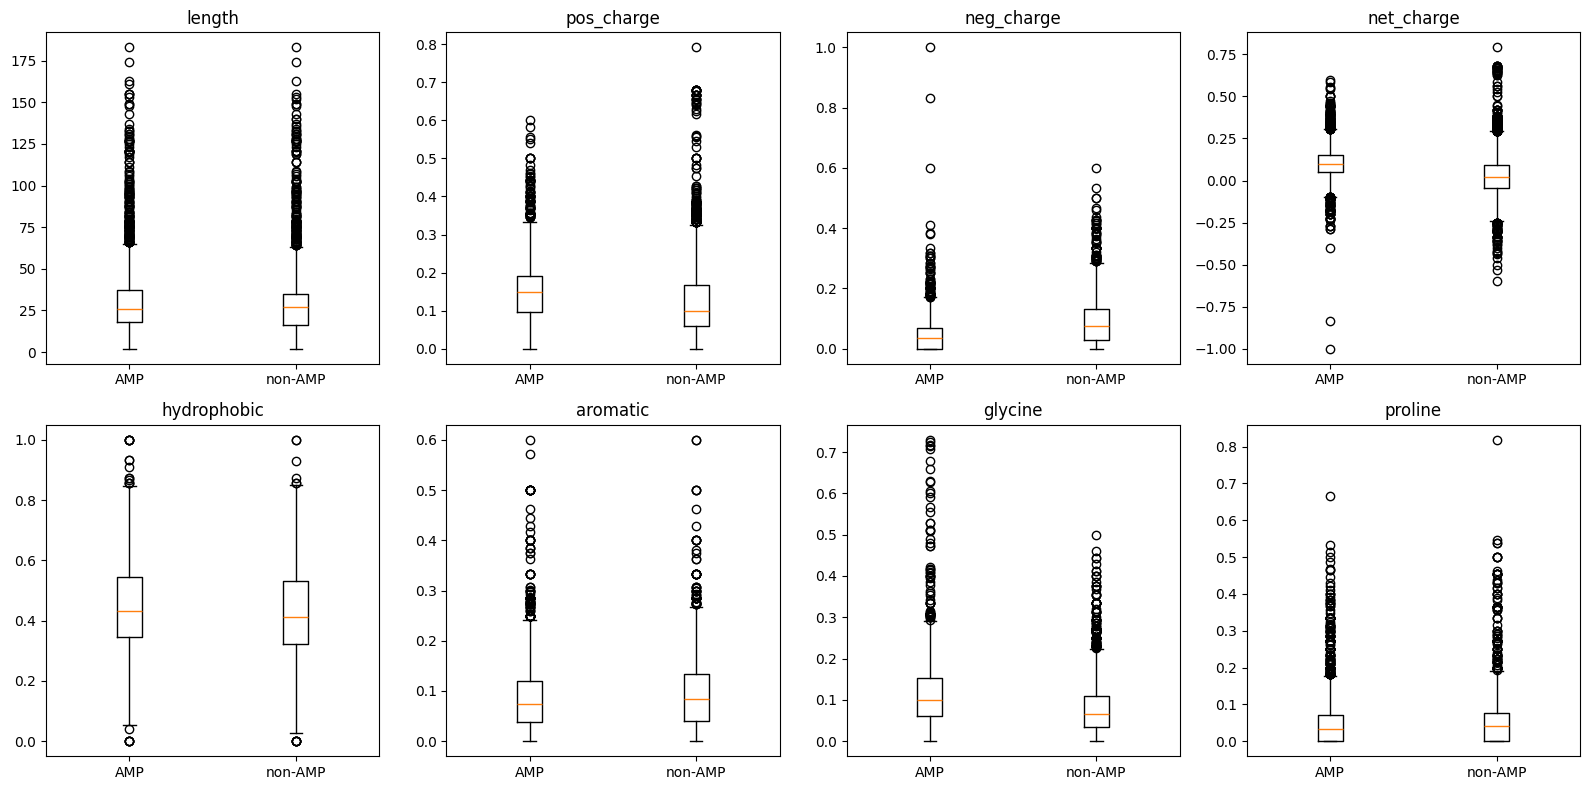

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

features_list = ["length", "pos_charge", "neg_charge", 
                 "net_charge", "hydrophobic", "aromatic", 
                 "glycine", "proline"]

for i, feat in enumerate(features_list):
    amp_data = df_features[df_features["label"]==1][feat]
    non_amp_data = df_features[df_features["label"]==0][feat]
    
    axes[i].boxplot([amp_data, non_amp_data], tick_labels=["AMP", "non-AMP"])
    axes[i].set_title(feat)

plt.tight_layout()
plt.savefig("eda_boxplot.png")
plt.show()

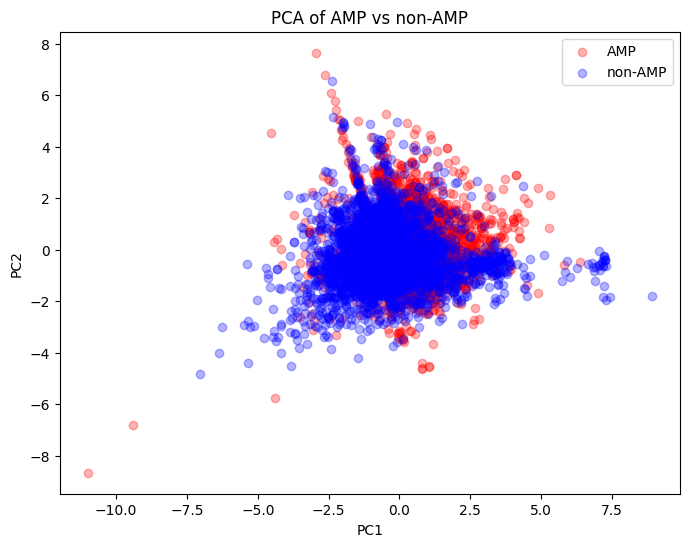

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_features.drop("label", axis=1)
y = df_features["label"]

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], alpha=0.3, label="AMP", color="red")
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], alpha=0.3, label="non-AMP", color="blue")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of AMP vs non-AMP")
plt.savefig("pca_plot.png")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Random Forest 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 평가
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["non-AMP", "AMP"]))

              precision    recall  f1-score   support

     non-AMP       0.84      0.85      0.84       647
         AMP       0.86      0.85      0.85       689

    accuracy                           0.85      1336
   macro avg       0.85      0.85      0.85      1336
weighted avg       0.85      0.85      0.85      1336



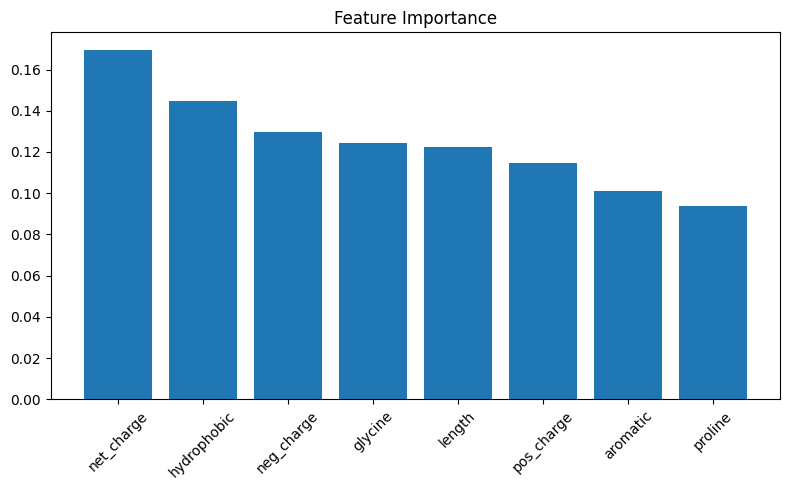

In [14]:
import numpy as np

feature_names = X.columns.tolist()
importances = rf.feature_importances_

# 정렬
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(len(feature_names)), importances[indices])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [15]:
# APD 데이터 읽기
def read_fasta(filename):
    sequences = {}
    with open(filename, "r") as f:
        current_id = None
        current_seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">AP0"):
                if current_id:
                    sequences[current_id] = current_seq
                current_id = line[1:]
                current_seq = ""
            elif current_id and line:
                current_seq += line
        if current_id:
            sequences[current_id] = current_seq
    return sequences

apd = read_fasta("results.fasta")
df_apd = pd.DataFrame({"id": list(apd.keys()), "sequence": list(apd.values())})

# feature 추출
features_apd = df_apd["sequence"].apply(extract_features)
df_apd_features = pd.DataFrame(list(features_apd))

# 정규화
X_apd = scaler.transform(df_apd_features)

# 예측
df_apd["amp_probability"] = rf.predict_proba(X_apd)[:, 1]
df_apd["prediction"] = rf.predict(X_apd)

# 상위 후보 출력
top_candidates = df_apd.sort_values("amp_probability", ascending=False).head(10)
print(top_candidates[["id", "sequence", "amp_probability"]])

          id                                        sequence  amp_probability
36   AP00104                                   FLPFLAKILTGVL              1.0
5    AP00015                                GLFDIVKKVVGALGSL              1.0
32   AP00094                                   FLPLIGRVLSGIL              1.0
873  AP02590           GFFCPYNGYCDRCRKKLRRRGGYCGGRWKLTCICIMN              1.0
29   AP00081  GIFSKLAGKKIKNLLISGLKNVGKEVGMDVVRTGIDIAGCKIKGEC              1.0
880  AP02607                           GLLSGILGAGKRIVCGLSGLC              1.0
881  AP02608                           GLLSGILGAGKKIVCGLSGLC              1.0
882  AP02609                        FFPLIAGLAARFLPKIFCSITKRC              1.0
884  AP02611                        VIPFVASVAAEMMQHVYCAASKRC              1.0
853  AP02475           GIFSLIKTAAKFVGKNLLKQAGKAGLEHLACKANNQC              1.0


In [16]:
def extract_features(seq):
    seq = seq.upper()
    length = len(seq)
    
    # 기존 feature
    pos_charge = (seq.count("K") + seq.count("R")) / length
    neg_charge = (seq.count("D") + seq.count("E")) / length
    net_charge = pos_charge - neg_charge
    hydrophobic = sum(seq.count(aa) for aa in "AVILMFWP") / length
    aromatic = sum(seq.count(aa) for aa in "FWY") / length
    glycine = seq.count("G") / length
    proline = seq.count("P") / length
    
    # 아미노산 20개 각각 비율 추가
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    aa_composition = {aa: seq.count(aa) / length for aa in amino_acids}
    
    result = {
        "length": length,
        "pos_charge": pos_charge,
        "neg_charge": neg_charge,
        "net_charge": net_charge,
        "hydrophobic": hydrophobic,
        "aromatic": aromatic,
        "glycine": glycine,
        "proline": proline
    }
    result.update(aa_composition)
    return result

# 다시 추출
features = df["sequence"].apply(extract_features)
df_features = pd.DataFrame(list(features))
df_features["label"] = df["label"]

print(f"총 feature 수: {df_features.shape[1]-1}개")

총 feature 수: 28개


In [17]:
X = df_features.drop("label", axis=1)
y = df_features["label"]

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Random Forest 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 평가
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["non-AMP", "AMP"]))


              precision    recall  f1-score   support

     non-AMP       0.88      0.91      0.89       647
         AMP       0.91      0.88      0.90       689

    accuracy                           0.89      1336
   macro avg       0.89      0.89      0.89      1336
weighted avg       0.89      0.89      0.89      1336



In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb, target_names=["non-AMP", "AMP"]))

              precision    recall  f1-score   support

     non-AMP       0.85      0.89      0.87       647
         AMP       0.89      0.85      0.87       689

    accuracy                           0.87      1336
   macro avg       0.87      0.87      0.87      1336
weighted avg       0.87      0.87      0.87      1336



In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

print("모델 비교 결과:")
print("-" * 35)
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"{name}: {acc:.3f}")

모델 비교 결과:
-----------------------------------
Random Forest: 0.894
Gradient Boosting: 0.870
Logistic Regression: 0.778
SVM: 0.899


In [20]:
# SVM 최종 모델로 상세 결과
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test, y_pred_svm, target_names=["non-AMP", "AMP"]))

C:\Users\82107\anaconda3\envs\nn\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

     non-AMP       0.89      0.91      0.90       647
         AMP       0.91      0.89      0.90       689

    accuracy                           0.90      1336
   macro avg       0.90      0.90      0.90      1336
weighted avg       0.90      0.90      0.90      1336



In [21]:
# APD 데이터 feature 추출
features_apd = df_apd["sequence"].apply(extract_features)
df_apd_features = pd.DataFrame(list(features_apd))

# 정규화
X_apd = scaler.transform(df_apd_features)

# SVM으로 예측
df_apd["amp_probability"] = svm.predict_proba(X_apd)[:, 1]
df_apd["prediction"] = svm.predict(X_apd)

# 상위 후보 출력
top_candidates = df_apd.sort_values("amp_probability", ascending=False).head(10)
print(top_candidates[["id", "sequence", "amp_probability"]])

# 저장
df_apd.to_csv("candidate_scores.csv", index=False)
print("저장 완료!")

           id                        sequence  amp_probability
511   AP01645  GAFGNFLKGVAKKAGLKILSIAQCKLFGTC         0.999998
844   AP02461        FLPGLIKAAVGVGSTILCKITKKC         0.999998
510   AP01644  GAFGNFLKGVAKKAGLKILSIAQCKLSGTC         0.999998
778   AP02282  GAFGNLLKGVAKKAGLKILSIAQCKLSGTC         0.999997
845   AP02462        FLPGLIKAAVGIGSTIFCKISKKC         0.999997
155   AP00390        FWGALIKGAAKLIPSVVGLFKKKQ         0.999997
943   AP02872           GIFSKLAGKKIKNLLISGLKG         0.999996
846   AP02463        FLPGLIKVAVGVGSTILCKITKKC         0.999996
1201  AP04269                  KILGKLWKGVKSIF         0.999995
1372  AP05737   GLWNSIKIAGKKLFVNVLDKIRCKVAGGC         0.999995
저장 완료!


In [22]:
# 웹사이트에서 서열 넣어보기
top_sequences = top_candidates["sequence"].tolist()
for seq in top_sequences:
    print(seq)

GAFGNFLKGVAKKAGLKILSIAQCKLFGTC
FLPGLIKAAVGVGSTILCKITKKC
GAFGNFLKGVAKKAGLKILSIAQCKLSGTC
GAFGNLLKGVAKKAGLKILSIAQCKLSGTC
FLPGLIKAAVGIGSTIFCKISKKC
FWGALIKGAAKLIPSVVGLFKKKQ
GIFSKLAGKKIKNLLISGLKG
FLPGLIKVAVGVGSTILCKITKKC
KILGKLWKGVKSIF
GLWNSIKIAGKKLFVNVLDKIRCKVAGGC
